# Artifacts, Testing, and Application Integration

**Purpose.** Verify that the committed AI/ML package is reproducible, portable, tested, and ready to be called by the application.

**Expected result.** Artifact integrity information for all categories, an actual structured prediction, runtime timing, and the current pytest result.

**Platform connection.** The FastAPI service supplies an image path and `InferenceConfig`, stores scalar outputs, and uploads image/heatmap assets. The ML module remains independent of MongoDB, Cloudinary, and frontend code.

In [1]:
from pathlib import Path
import json
import os
import sys

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import JSON, Markdown, display

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "ml").exists():
    raise RuntimeError("Run this notebook from the repository root or notebooks directory.")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

def locate_mvtec_root() -> Path:
    configured = os.getenv("MVTEC_DATASET_ROOT")
    candidates = [
        Path(configured).expanduser() if configured else None,
        PROJECT_ROOT / "data" / "raw" / "mvtec_anomaly_detection",
        PROJECT_ROOT.parent / "visioninspect-ai-github" / "data" / "raw" / "mvtec_anomaly_detection",
        PROJECT_ROOT.parent / "visioninspect-ai" / "data" / "raw" / "mvtec_anomaly_detection",
        PROJECT_ROOT.parent / "visioninspect-ai" / "data" / "raw" / "mvtec_anomaly_detection1",
    ]
    for candidate in candidates:
        if candidate and candidate.exists():
            return candidate.resolve()
    raise FileNotFoundError(
        "MVTec AD was not found. Set MVTEC_DATASET_ROOT or place the dataset under "
        "data/raw/mvtec_anomaly_detection."
    )

DATASET_ROOT = locate_mvtec_root()
IMAGE_EXTENSIONS = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff", ".webp"}

def image_files(directory: Path) -> list[Path]:
    if not directory.exists():
        return []
    return sorted(path for path in directory.iterdir() if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS)

def first_test_image(category: str, label: str) -> Path:
    paths = image_files(DATASET_ROOT / category / "test" / label)
    if not paths:
        raise FileNotFoundError(f"No {category}/{label} test image was found.")
    return paths[0]

def first_defect(category: str) -> tuple[str, Path]:
    test_root = DATASET_ROOT / category / "test"
    defect_dirs = sorted(path for path in test_root.iterdir() if path.is_dir() and path.name != "good")
    for directory in defect_dirs:
        paths = image_files(directory)
        if paths:
            return directory.name, paths[0]
    raise FileNotFoundError(f"No defective test image was found for {category}.")

def mask_path_for(category: str, label: str, image_path: Path) -> Path | None:
    if label == "good":
        return None
    candidate = DATASET_ROOT / category / "ground_truth" / label / f"{image_path.stem}_mask.png"
    return candidate if candidate.exists() else None

def read_rgb(path: Path) -> np.ndarray:
    image = cv2.imread(str(path))
    if image is None:
        raise FileNotFoundError(f"Could not read image: {path}")
    return cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

print(f"Project root: {PROJECT_ROOT}")
print(f"MVTec root:  {DATASET_ROOT}")

Project root: C:\Users\HP\Desktop\springboard\VisionInspectAI-team
MVTec root:  C:\Users\HP\Desktop\springboard\visioninspect-ai-github\data\raw\mvtec_anomaly_detection


In [2]:
from ml.model_registry import category_model_statuses

statuses = category_model_statuses(advanced_enabled=False, openvino_enabled=True)
status_rows = []
for status in statuses:
    artifacts = status["artifacts"]
    total_bytes = sum(item["size_bytes"] for item in artifacts.values() if item)
    status_rows.append(
        {
            "category": status["category"],
            "runnable": status["runnable"],
            "classifier_ready": status["classification_trained"],
            "preferred_model": status["model_kind"],
            "active_portable_engine": status["active_engine"],
            "profile": artifacts["profile"]["file"] if artifacts["profile"] else None,
            "classifier": artifacts["classifier"]["file"] if artifacts["classifier"] else None,
            "cnn_onnx": artifacts["cnn_classifier"]["file"] if artifacts["cnn_classifier"] else None,
            "artifact_size_mb": round(total_bytes / (1024 ** 2), 2),
            "profile_sha256_prefix": artifacts["profile"]["sha256"][:12] if artifacts["profile"] else None,
        }
    )
status_df = pd.DataFrame(status_rows)
display(status_df)
print(f"Runnable categories: {status_df['runnable'].sum()} / {len(status_df)}")
print(f"Categories with subtype classifier: {status_df['classifier_ready'].sum()} / {len(status_df)}")

,category,runnable,classifier_ready,preferred_model,active_portable_engine,profile,classifier,cnn_onnx,artifact_size_mb,profile_sha256_prefix
0,bottle,True,True,padim,opencv-baseline,normal_profile.npz,defect_classifier.pkl,NaN,1.73,0aae2b9a0740
1,cable,True,True,patchcore,patchcore_openvino,normal_profile.npz,defect_classifier.pkl,NaN,2.89,0caeeb6f29d1
2,capsule,True,True,padim,opencv-baseline,normal_profile.npz,defect_classifier.pkl,cnn_defect_classifier.onnx,69.30,d97442d7b6c2
3,carpet,True,True,padim,opencv-baseline,normal_profile.npz,defect_classifier.pkl,NaN,19.27,77f90e3051d3
4,grid,True,True,padim,opencv-baseline,normal_profile.npz,defect_classifier.pkl,NaN,1.64,2cc58cbb9d23
5,hazelnut,True,True,patchcore,opencv-baseline,normal_profile.npz,defect_classifier.pkl,NaN,2.16,979367a98857
6,leather,True,True,padim,opencv-baseline,normal_profile.npz,defect_classifier.pkl,NaN,2.66,1bd825a39262
7,metal_nut,True,True,padim,opencv-baseline,normal_profile.npz,defect_classifier.pkl,NaN,19.27,947bc62806f0
8,pill,True,True,padim,opencv-baseline,normal_profile.npz,defect_classifier.pkl,NaN,19.36,016c6ee6a5ae
9,screw,True,True,patchcore,opencv-baseline,normal_profile.npz,defect_classifier.pkl,NaN,3.58,f51c86957cd3


Runnable categories: 15 / 15
Categories with subtype classifier: 15 / 15


In [3]:
from dataclasses import replace
from time import perf_counter

from ml.inference import baseline_anomaly_prediction, inspect_image as inspect_image_runtime
from ml.predict import build_inference_config

category = "cable"
config = replace(
    build_inference_config(category),
    use_padim_inference=False,
    use_openvino_inference=False,
    openvino_path=None,
    openvino_calibrator_path=None,
    critical_zones=("center", "edge"),
)

label = None
image_path = None
for directory in sorted((DATASET_ROOT / category / "test").iterdir()):
    if not directory.is_dir() or directory.name == "good":
        continue
    for candidate in image_files(directory)[:5]:
        candidate_bgr = cv2.imread(str(candidate))
        candidate_result = baseline_anomaly_prediction(candidate, candidate_bgr, config)
        if candidate_result["is_defective"]:
            label, image_path = directory.name, candidate
            break
    if image_path is not None:
        break
if image_path is None:
    raise RuntimeError("No detected cable defect was found in the diagnostic search window.")

started = perf_counter()
result = inspect_image_runtime(image_path, config)
elapsed_ms = (perf_counter() - started) * 1000

api_payload = {
    "input_image": str(image_path),
    "expected_subtype": label,
    "category": result["model_category"],
    "prediction": result["prediction"],
    "defect_type": result["defect_type"],
    "confidence": result["confidence"],
    "detection_confidence": result["detection_confidence"],
    "classification_confidence": result["classification_confidence"],
    "anomaly_score": result["anomaly_score"],
    "defect_area_ratio": result["defect_area_ratio"],
    "class_probabilities": result["class_probabilities"],
    "severity_score": result["severity_score"],
    "severity_level": result["severity_level"],
    "severity_components": result["severity_components"],
    "pass_fail": result["pass_fail"],
    "recommended_action": result["recommended_action"],
    "model_used": result["model_used"],
    "active_inference_engine": result["active_inference_engine"],
    "fallback_used": result["fallback_used"],
    "fallback_reason": result["fallback_reason"],
    "explainability": result["explainability"],
    "inference_time_ms": round(elapsed_ms, 1),
    "heatmap": "NumPy image returned in-process; storage is owned by the application service",
}
display(JSON(api_payload))

<IPython.core.display.JSON object>

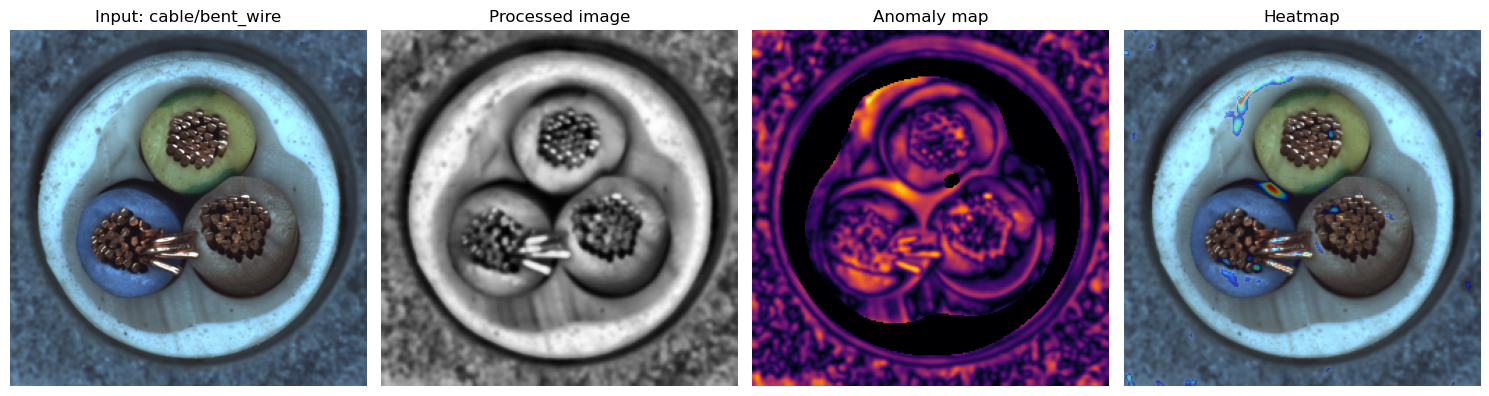

In [4]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
axes[0].imshow(read_rgb(image_path))
axes[0].set_title(f"Input: {category}/{label}")
axes[1].imshow(result["processed_image"], cmap="gray")
axes[1].set_title("Processed image")
axes[2].imshow(result["anomaly_map"], cmap="inferno")
axes[2].set_title("Anomaly map")
axes[3].imshow(cv2.cvtColor(result["heatmap_image"], cv2.COLOR_BGR2RGB))
axes[3].set_title("Heatmap")
for axis in axes:
    axis.axis("off")
plt.tight_layout()
plt.show()

In [5]:
import subprocess

completed = subprocess.run(
    [sys.executable, "-m", "pytest", "-q"],
    cwd=PROJECT_ROOT,
    capture_output=True,
    text=True,
    timeout=180,
)
print(completed.stdout)
if completed.stderr.strip():
    print(completed.stderr)
print(f"pytest exit code: {completed.returncode}")
if completed.returncode != 0:
    raise RuntimeError("The AI/ML test suite did not pass.")

............s...s...................                                     [100%]
34 passed, 2 skipped in 6.57s

pytest exit code: 0


## Integration boundary

| Owner | Responsibility |
|---|---|
| AI/ML module | Validate/read image, detect anomaly, classify subtype, localize defect, score severity, return arrays and structured values |
| Backend | Authentication, request validation, category/metadata selection, calling ML, persistence, audit logging, report orchestration |
| Storage/database | Store inspection records and published image/heatmap/report URLs |
| Frontend | Upload workflow, result visualization, manual review, analytics, reports, and role-based controls |

The ML runtime intentionally does not save notebook screenshots or report files. Arrays are returned in memory; the application decides where and how to persist them.

## Final conclusion

The Member 4 package supports all 15 MVTec categories through a registry-driven inference contract. It includes a portable ResNet18/OpenCV anomaly detector, category-selected PaDiM or PatchCore metadata, an executable cable OpenVINO path, category-specific subtype classifiers, localization and explainability, weighted severity scoring, model-development scripts, integrity checks, and automated tests. The recorded evaluation also identifies where category-specific model improvement is still required.